In [ ]:
from google.colab import files

uploaded = files.upload()


Saving activity_12_-_man_walking.mp4.mp4 to activity_12_-_man_walking.mp4 (1).mp4


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 6.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import os

from ultralytics import YOLO
from torchvision import models, transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
from sklearn.metrics.pairwise import cosine_similarity

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
import os

# Automatically find the uploaded MP4 file to prevent path mismatch
uploaded_files = [f for f in os.listdir('.') if f.endswith('.mp4')]
if uploaded_files:
    # Use the most recently uploaded file containing the activity name
    VIDEO_PATH = uploaded_files[-1]
else:
    VIDEO_PATH = "activity_12_-_man_walking.mp4"

print(f"Using video file: {VIDEO_PATH}")
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Total frames:", total_frames)

if fps > 0:
    print("Duration:", total_frames / fps)
    # Use first 10 seconds
    max_frames = int(min(total_frames, fps * 10))
else:
    print("Error: Could not read video file property. Please make sure the path is correct.")
    max_frames = 0

frames = []

for i in range(max_frames):
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

cap.release()

print("Frames extracted:", len(frames))

Using video file: activity_12_-_man_walking.mp4 (1).mp4
FPS: 25.0
Total frames: 359
Duration: 14.36
Frames extracted: 250


In [ ]:
num_samples = 16

indices = np.linspace(
    0,
    len(frames) - 1,
    num_samples
).astype(int)

sample_frames = [frames[i] for i in indices]

print("Selected frames:", len(sample_frames))

Selected frames: 16


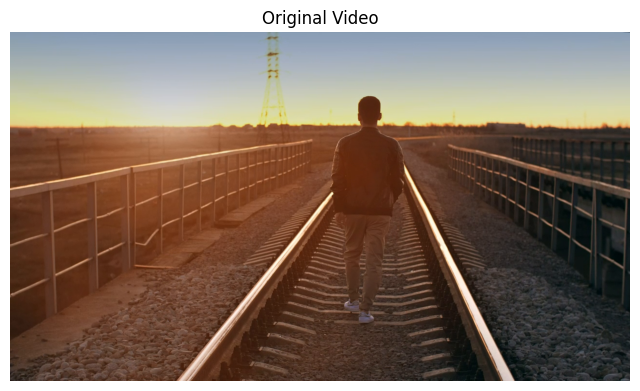

In [ ]:
original_frame = sample_frames[len(sample_frames)//2]

plt.figure(figsize=(8,5))
plt.imshow(original_frame)
plt.title("Original Video")
plt.axis("off")
plt.show()

In [ ]:
yolo = YOLO("yolov8n.pt")

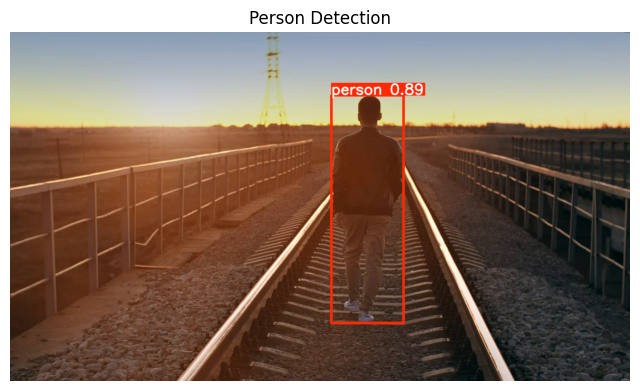

In [ ]:
result = yolo.predict(
    source=original_frame,
    classes=[0],       # person class
    conf=0.4,
    verbose=False
)[0]

person_detection = result.plot()

plt.figure(figsize=(8,5))
plt.imshow(person_detection)
plt.title("Person Detection")
plt.axis("off")
plt.show()

In [ ]:
gray1 = cv2.cvtColor(
    sample_frames[5],
    cv2.COLOR_RGB2GRAY
)

gray2 = cv2.cvtColor(
    sample_frames[6],
    cv2.COLOR_RGB2GRAY
)

flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

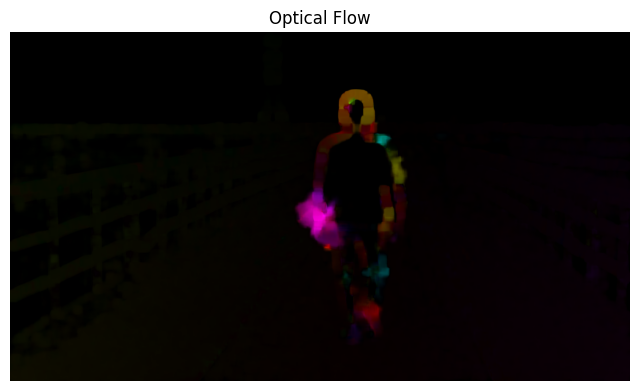

In [ ]:
magnitude, angle = cv2.cartToPolar(
    flow[...,0],
    flow[...,1]
)

hsv = np.zeros_like(sample_frames[5])
hsv[...,1] = 255

hsv[...,0] = angle * 180 / np.pi / 2
hsv[...,2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

optical_flow = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(8,5))
plt.imshow(optical_flow)
plt.title("Optical Flow")
plt.axis("off")
plt.show()

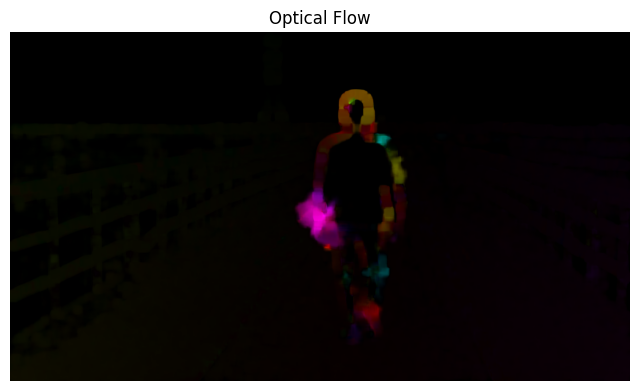

In [ ]:
magnitude, angle = cv2.cartToPolar(
    flow[...,0],
    flow[...,1]
)

hsv = np.zeros_like(sample_frames[5])
hsv[...,1] = 255

hsv[...,0] = angle * 180 / np.pi / 2
hsv[...,2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

optical_flow = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(8,5))
plt.imshow(optical_flow)
plt.title("Optical Flow")
plt.axis("off")
plt.show()

In [ ]:
gray_frames = [
    cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    for frame in sample_frames
]

mhi = np.zeros_like(gray_frames[0], dtype=np.float32)

timestamp = 1

for i in range(1, len(gray_frames)):

    diff = cv2.absdiff(
        gray_frames[i],
        gray_frames[i-1]
    )

    _, motion = cv2.threshold(
        diff,
        25,
        1,
        cv2.THRESH_BINARY
    )

    mhi[motion == 1] = timestamp

    timestamp += 1

motion_history = cv2.normalize(
    mhi,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

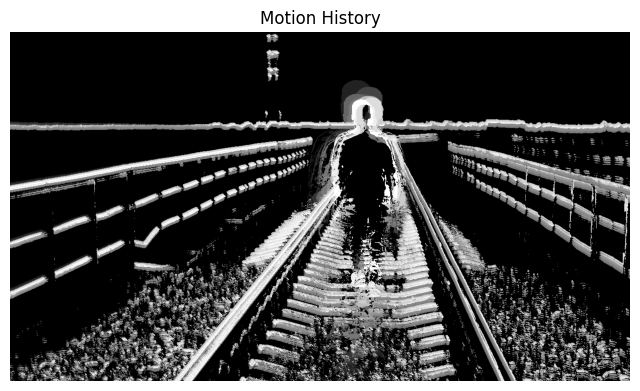

In [ ]:
plt.figure(figsize=(8,5))
plt.imshow(motion_history, cmap="gray")
plt.title("Motion History")
plt.axis("off")
plt.show()

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = models.ResNet18_Weights.DEFAULT

resnet = models.resnet18(
    weights=weights
)

resnet = torch.nn.Sequential(
    *list(resnet.children())[:-1]
)

resnet = resnet.to(device)
resnet.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
preprocess = weights.transforms()

In [ ]:
cnn_features = []

# Convert NumPy array frames to PyTorch Tensors for torchvision models
to_tensor = transforms.ToTensor()

with torch.no_grad():

    for frame in sample_frames:
        # Convert numpy.ndarray to a PyTorch Tensor [C, H, W]
        tensor_frame = to_tensor(frame)

        image = preprocess(
            tensor_frame
        ).unsqueeze(0).to(device)

        feature = resnet(image)

        feature = feature.flatten()

        cnn_features.append(
            feature.cpu().numpy()
        )

cnn_features = np.array(cnn_features)

print("CNN feature shape:", cnn_features.shape)

CNN feature shape: (16, 512)


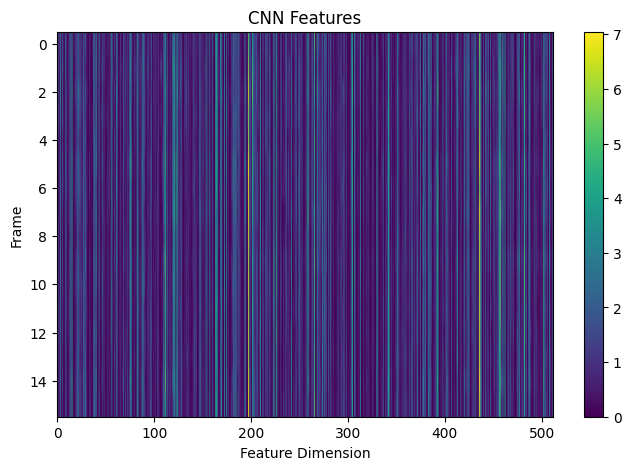

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    cnn_features,
    aspect="auto"
)

plt.colorbar()

plt.title("CNN Features")
plt.xlabel("Feature Dimension")
plt.ylabel("Frame")

plt.show()

In [ ]:
lstm = torch.nn.LSTM(
    input_size=512,
    hidden_size=128,
    num_layers=1,
    batch_first=True
).to(device)

lstm.eval()

LSTM(512, 128, batch_first=True)

In [ ]:
sequence = torch.tensor(
    cnn_features,
    dtype=torch.float32
).unsqueeze(0).to(device)

In [ ]:
with torch.no_grad():

    lstm_output, _ = lstm(sequence)

lstm_features = (
    lstm_output
    .squeeze(0)
    .cpu()
    .numpy()
)

print("CNN-LSTM feature shape:", lstm_features.shape)


CNN-LSTM feature shape: (16, 128)


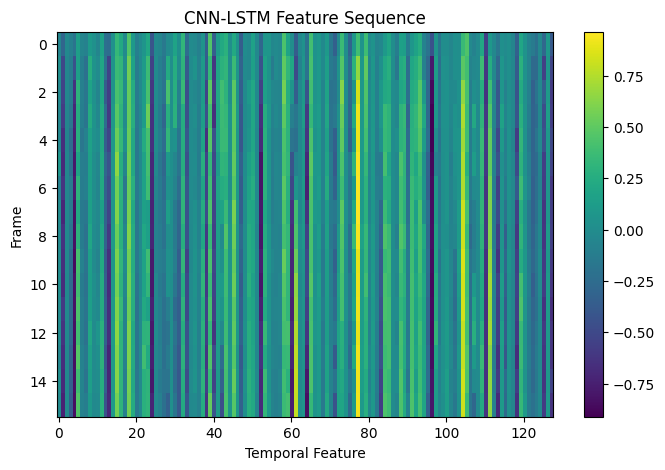

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    lstm_features,
    aspect="auto"
)

plt.colorbar()

plt.title("CNN-LSTM Feature Sequence")

plt.xlabel("Temporal Feature")
plt.ylabel("Frame")

plt.show()

In [ ]:
video_weights = R3D_18_Weights.DEFAULT

r3d = r3d_18(
    weights=video_weights
)

r3d = torch.nn.Sequential(
    *list(r3d.children())[:-1]
)

r3d = r3d.to(device)
r3d.eval()

print("3D CNN model loaded")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 89.7MB/s]


3D CNN model loaded


In [ ]:
video_transform = video_weights.transforms()
to_tensor = transforms.ToTensor()

# 1. Convert and stack individual frames to get a 4D tensor: [T, C, H, W]
raw_video_tensor = torch.stack([
    to_tensor(frame)
    for frame in sample_frames
])

# 2. Add a batch dimension to make it a 5D tensor: [1, T, C, H, W]
raw_video_tensor = raw_video_tensor.unsqueeze(0)

# 3. Apply the video preset transform to the 5D video batch
video_tensor = video_transform(raw_video_tensor)

print("Video tensor shape for 3D CNN:", video_tensor.shape)

Video tensor shape for 3D CNN: torch.Size([1, 3, 16, 112, 112])


In [ ]:
# The tensor is already correctly formatted as 5D [Batch, Channels, Time, Height, Width]
# We just need to move it to the device
video_tensor = video_tensor.to(device)

print("3D CNN input shape:", video_tensor.shape)

3D CNN input shape: torch.Size([1, 3, 16, 112, 112])


In [ ]:
with torch.no_grad():

    video_features = r3d(
        video_tensor
    )

video_features = (
    video_features
    .flatten()
    .cpu()
    .numpy()
)

print(
    "3D CNN feature shape:",
    video_features.shape
)

3D CNN feature shape: (512,)


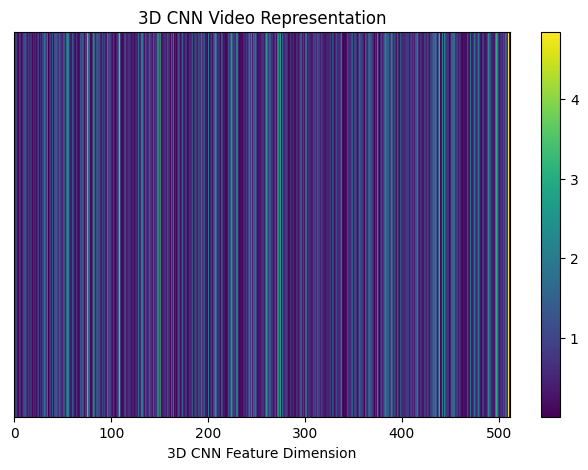

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    video_features.reshape(1, -1),
    aspect="auto"
)

plt.colorbar()

plt.title("3D CNN Video Representation")

plt.xlabel("3D CNN Feature Dimension")
plt.yticks([])

plt.show()

In [ ]:
similarity = cosine_similarity(
    cnn_features
)

print("Similarity matrix shape:", similarity.shape)

Similarity matrix shape: (16, 16)


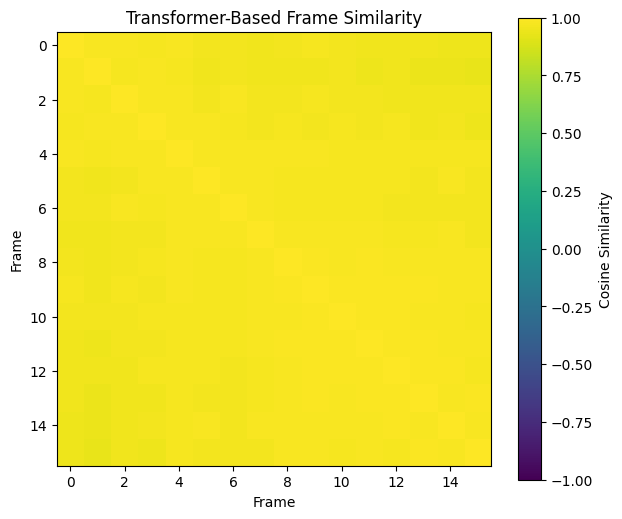

In [ ]:
plt.figure(figsize=(7,6))

plt.imshow(
    similarity,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Cosine Similarity"
)

plt.title(
    "Transformer-Based Frame Similarity"
)

plt.xlabel("Frame")
plt.ylabel("Frame")

plt.show()

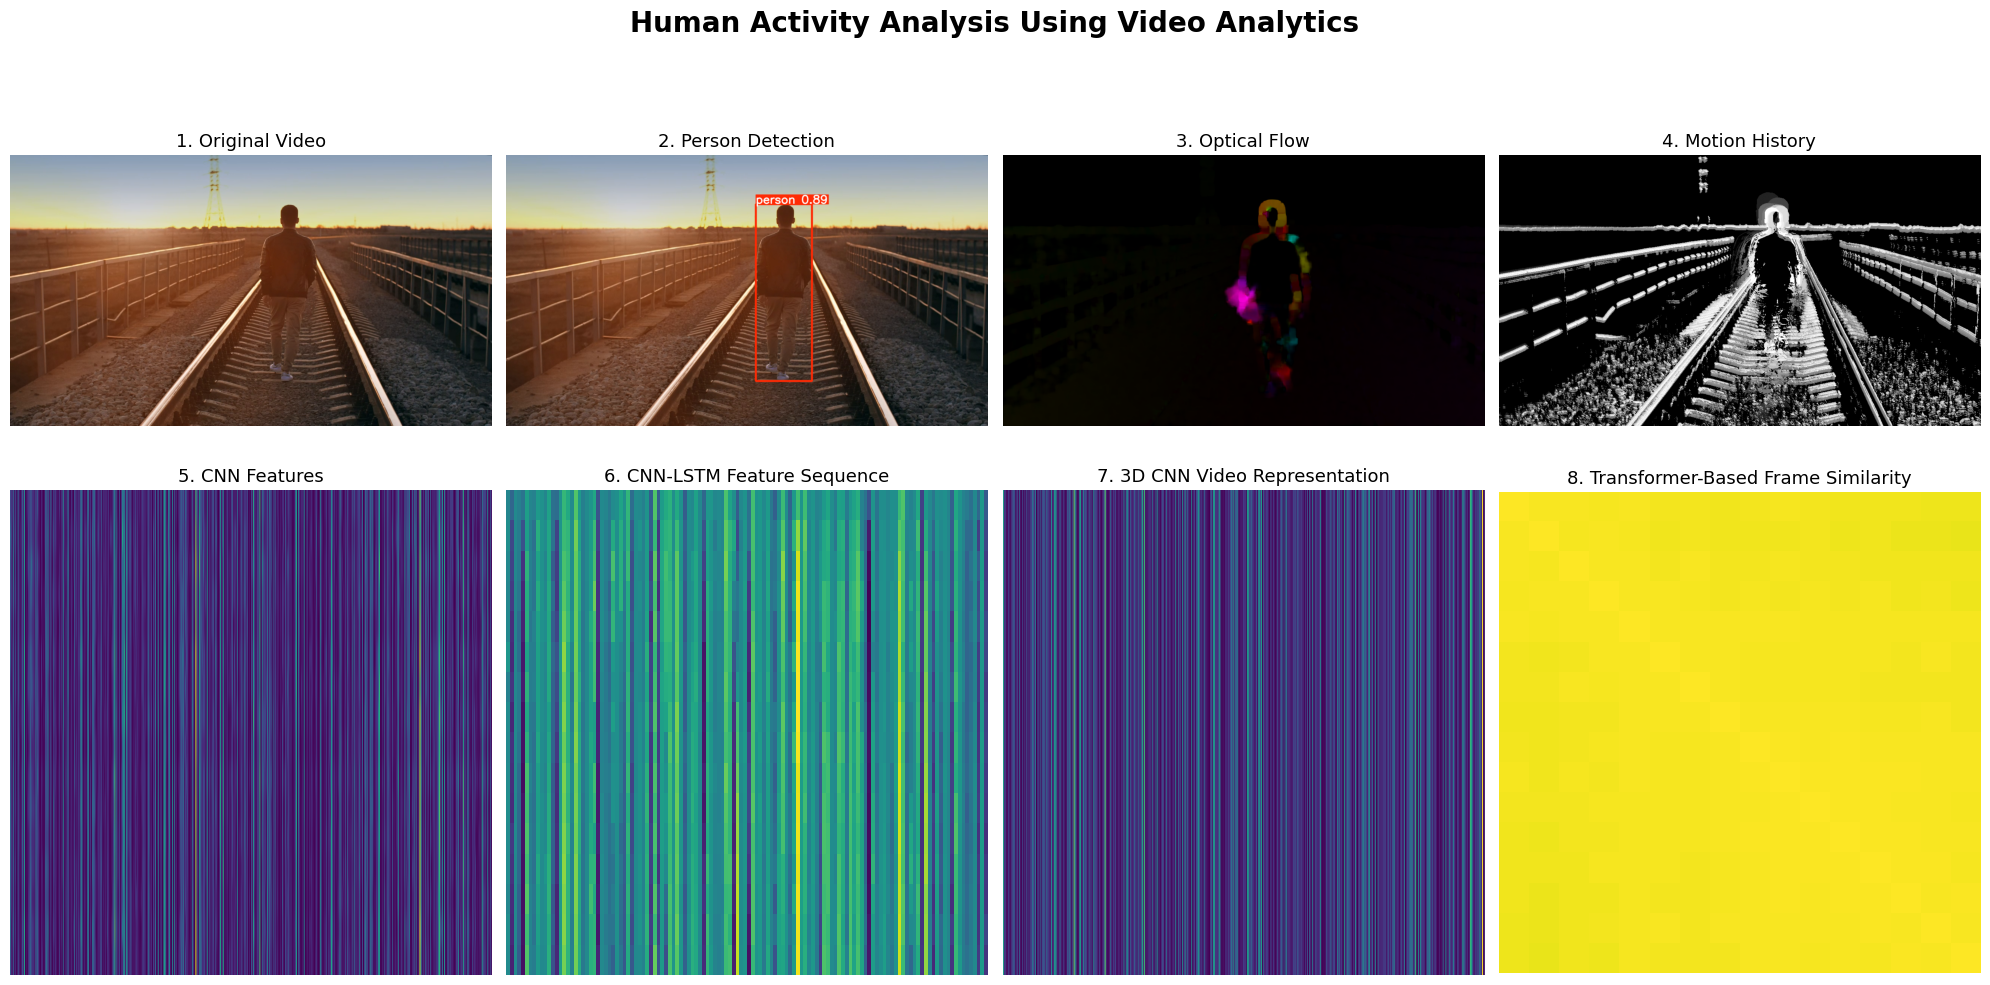

In [ ]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(20,10)
)

# --------------------------------
# 1. Original Video
# --------------------------------
axes[0,0].imshow(original_frame)
axes[0,0].set_title(
    "1. Original Video",
    fontsize=13
)

# --------------------------------
# 2. Person Detection
# --------------------------------
axes[0,1].imshow(person_detection)
axes[0,1].set_title(
    "2. Person Detection",
    fontsize=13
)

# --------------------------------
# 3. Optical Flow
# --------------------------------
axes[0,2].imshow(optical_flow)
axes[0,2].set_title(
    "3. Optical Flow",
    fontsize=13
)

# --------------------------------
# 4. Motion History
# --------------------------------
axes[0,3].imshow(
    motion_history,
    cmap="gray"
)
axes[0,3].set_title(
    "4. Motion History",
    fontsize=13
)

# --------------------------------
# 5. CNN Features
# --------------------------------
axes[1,0].imshow(
    cnn_features,
    aspect="auto"
)
axes[1,0].set_title(
    "5. CNN Features",
    fontsize=13
)

# --------------------------------
# 6. CNN-LSTM
# --------------------------------
axes[1,1].imshow(
    lstm_features,
    aspect="auto"
)
axes[1,1].set_title(
    "6. CNN-LSTM Feature Sequence",
    fontsize=13
)

# --------------------------------
# 7. 3D CNN
# --------------------------------
axes[1,2].imshow(
    video_features.reshape(1,-1),
    aspect="auto"
)
axes[1,2].set_title(
    "7. 3D CNN Video Representation",
    fontsize=13
)

# --------------------------------
# 8. Transformer
# --------------------------------
axes[1,3].imshow(
    similarity,
    cmap="viridis",
    vmin=-1,
    vmax=1
)
axes[1,3].set_title(
    "8. Transformer-Based Frame Similarity",
    fontsize=13
)

# Remove axes
for ax in axes.flat:
    ax.axis("off")

plt.suptitle(
    "Human Activity Analysis Using Video Analytics",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "human_activity_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
with torch.no_grad():
    lstm_output, _ = lstm(sequence)

lstm_features = (
    lstm_output
    .squeeze(0)
    .cpu()
    .numpy()
)

print("CNN-LSTM feature shape:", lstm_features.shape)

CNN-LSTM feature shape: (16, 128)


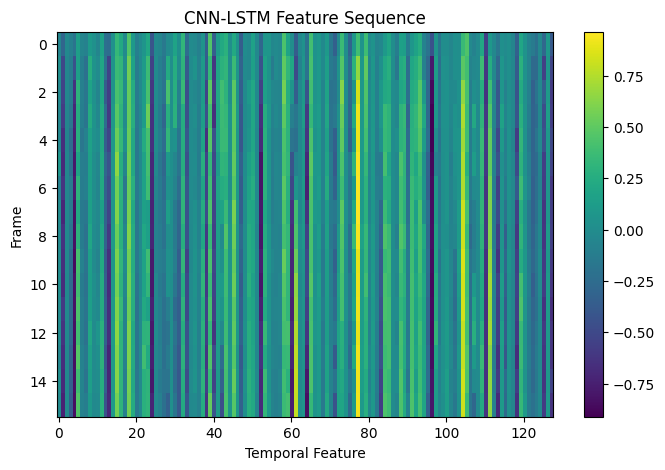

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    lstm_features,
    aspect="auto"
)

plt.colorbar()

plt.title("CNN-LSTM Feature Sequence")
plt.xlabel("Temporal Feature")
plt.ylabel("Frame")

plt.show()

In [ ]:
video_weights = R3D_18_Weights.DEFAULT

r3d = r3d_18(
    weights=video_weights
)

r3d = torch.nn.Sequential(
    *list(r3d.children())[:-1]
)

r3d = r3d.to(device)
r3d.eval()

print("3D CNN model loaded")

3D CNN model loaded


In [ ]:
video_transform = video_weights.transforms()
to_tensor = transforms.ToTensor()

# 1. Convert and stack individual frames to get a 4D tensor: [T, C, H, W]
raw_video_tensor = torch.stack([
    to_tensor(frame)
    for frame in sample_frames
])

# 2. Add a batch dimension to make it a 5D tensor: [1, T, C, H, W]
raw_video_tensor = raw_video_tensor.unsqueeze(0)

# 3. Apply the video preset transform to the 5D video batch
video_tensor = video_transform(raw_video_tensor)

print("Before rearranging:", video_tensor.shape)

Before rearranging: torch.Size([1, 3, 16, 112, 112])


In [ ]:
video_tensor = video_tensor.to(device)

print("3D CNN input shape:", video_tensor.shape)

3D CNN input shape: torch.Size([1, 3, 16, 112, 112])


In [ ]:
with torch.no_grad():

    video_features = r3d(
        video_tensor
    )

video_features = (
    video_features
    .flatten()
    .cpu()
    .numpy()
)

print("3D CNN feature shape:", video_features.shape)

3D CNN feature shape: (512,)


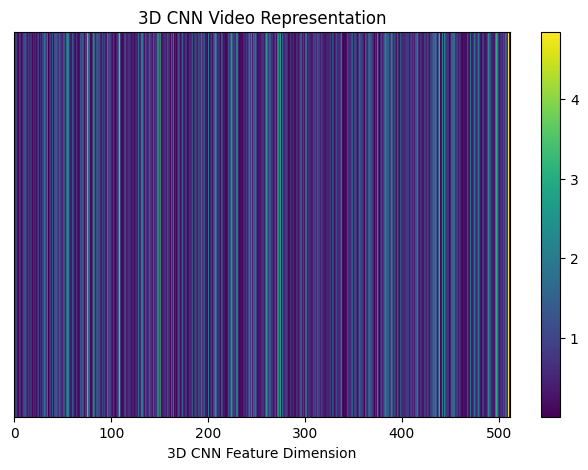

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(
    video_features.reshape(1, -1),
    aspect="auto"
)

plt.colorbar()

plt.title("3D CNN Video Representation")
plt.xlabel("3D CNN Feature Dimension")
plt.yticks([])

plt.show()

In [ ]:
similarity = cosine_similarity(
    cnn_features
)

print("Similarity matrix shape:", similarity.shape)

Similarity matrix shape: (16, 16)


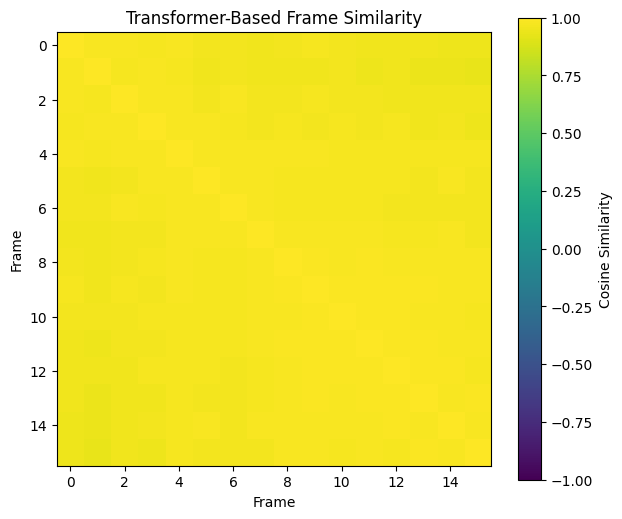

In [ ]:
plt.figure(figsize=(7,6))

plt.imshow(
    similarity,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Cosine Similarity"
)

plt.title(
    "Transformer-Based Frame Similarity"
)

plt.xlabel("Frame")
plt.ylabel("Frame")

plt.show()

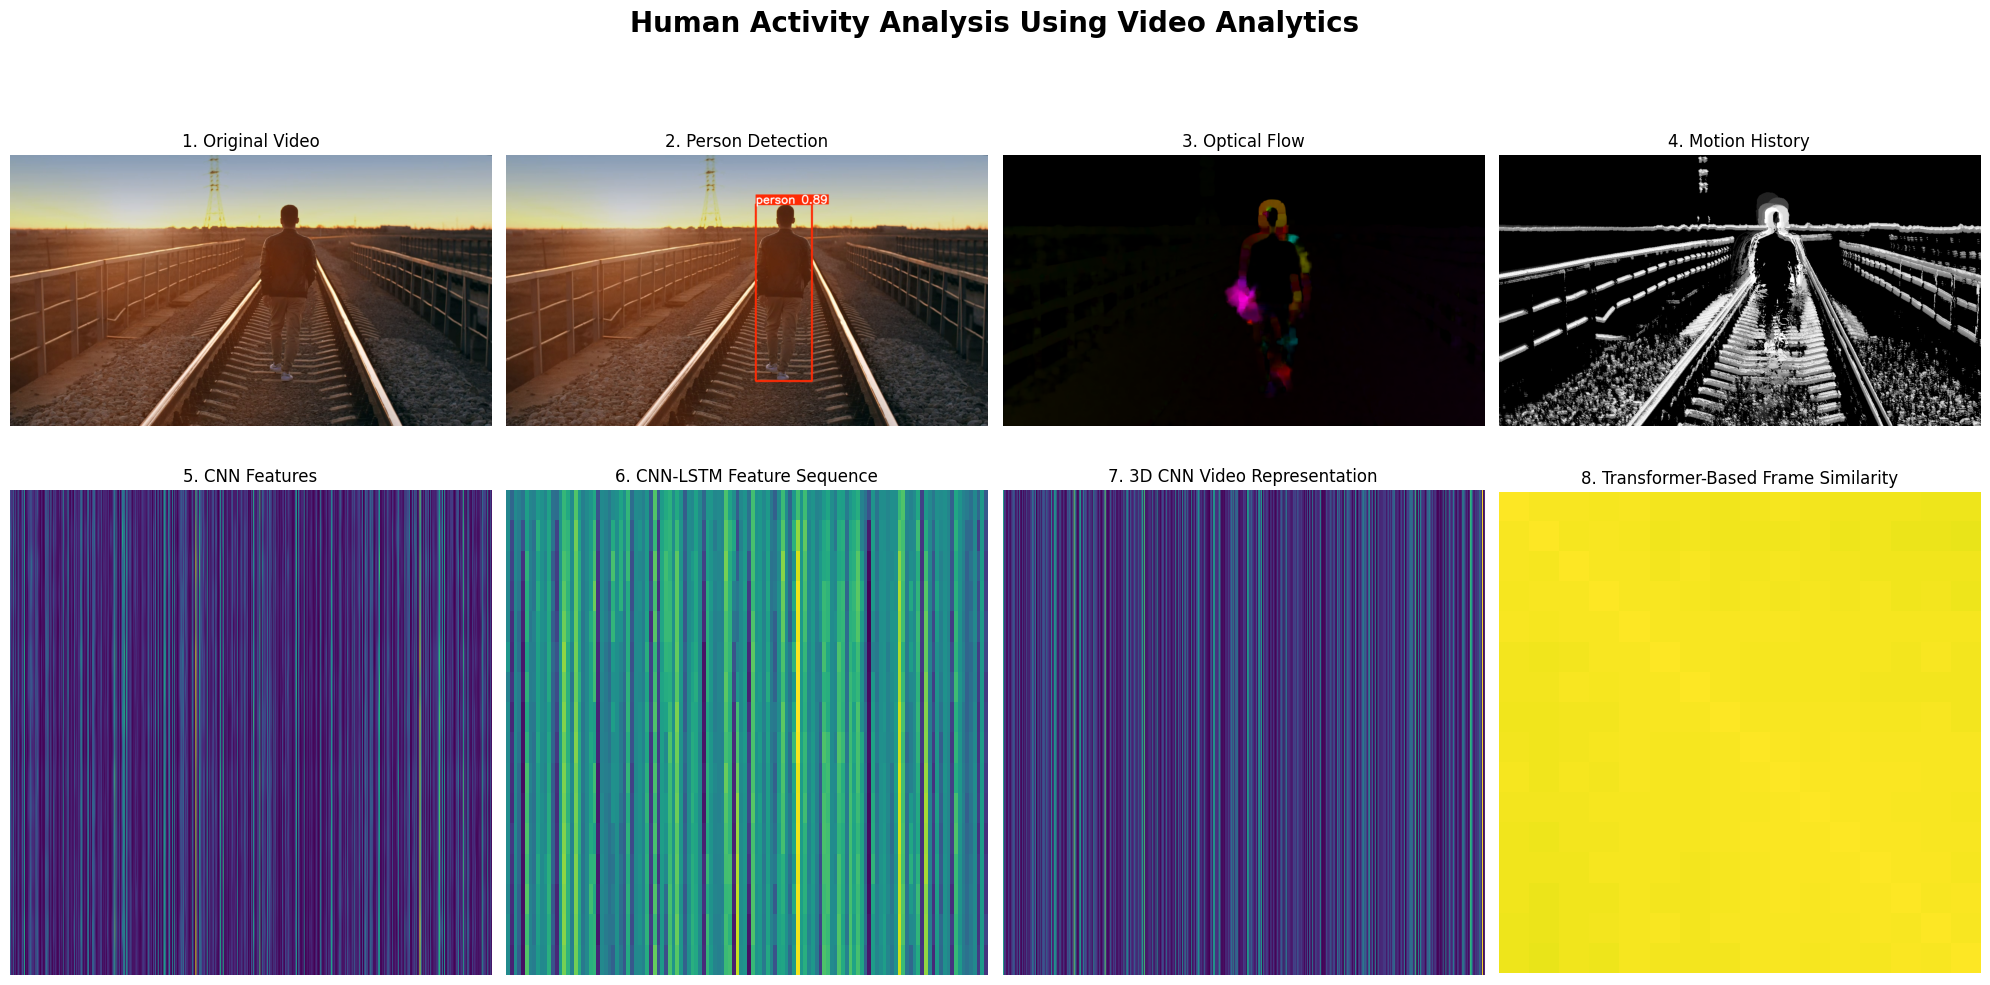

In [ ]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(20, 10)
)

axes[0,0].imshow(original_frame)
axes[0,0].set_title("1. Original Video")

axes[0,1].imshow(person_detection)
axes[0,1].set_title("2. Person Detection")

axes[0,2].imshow(optical_flow)
axes[0,2].set_title("3. Optical Flow")

axes[0,3].imshow(motion_history, cmap="gray")
axes[0,3].set_title("4. Motion History")

axes[1,0].imshow(cnn_features, aspect="auto")
axes[1,0].set_title("5. CNN Features")

axes[1,1].imshow(lstm_features, aspect="auto")
axes[1,1].set_title("6. CNN-LSTM Feature Sequence")

axes[1,2].imshow(
    video_features.reshape(1,-1),
    aspect="auto"
)
axes[1,2].set_title("7. 3D CNN Video Representation")

axes[1,3].imshow(
    similarity,
    cmap="viridis",
    vmin=-1,
    vmax=1
)
axes[1,3].set_title("8. Transformer-Based Frame Similarity")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(
    "Human Activity Analysis Using Video Analytics",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "human_activity_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()